<a href="https://colab.research.google.com/github/Somaskandan931/flyrank-ml-2026-Somaskandan931/blob/main/work/notebooks/w07_action_playbook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ML-10 — Content Action Playbook

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Somaskandan931/flyrank-ml-2026-Somaskandan931/blob/main/work/notebooks/w07_action_playbook.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Ranked actions + reason codes

*The queue: what to do first, and why, in words a human trusts.*

**The decay/refresh insight this playbook is built on:** a page doesn't have to lose
impressions to be decaying — a CTR gap against its own position band's benchmark, at
stable or even growing impression volume, is the earliest and most actionable decay
signal (that's what the Week-4 baseline score already measures). The Week-5/6 model
adds a second, independent layer: does the same page also look likely to gain clicks
in the second half of the month, based only on its first-half behavior? Combining the
two gives archetypes a human can act on with a clear reason, instead of a single
opaque score.

**How the queue is built:**
1. Rebuild the Week-4 baseline exactly (whole-March CTR-vs-position-benchmark score,
   reason code `CTR_BELOW_POSITION_BENCHMARK`) — the current-state signal, covers
   every page.
2. Rebuild the Week-5/6 honest model, but keep its score ONLY for rows that actually
   fell in the client-grouped holdout split. Applying the model's score to its own
   training rows would be reusing memorized information as if it were a prediction —
   the whole point of the ML-09 audit was to catch exactly that mistake, so it
   shouldn't resurface here.
3. Cross the two into archetypes, each with one action and a one-line cost/value reason:

| Archetype | Condition | Action | Cost/value logic |
|---|---|---|---|
| `CONFIRMED_PRIORITY` | baseline flags it AND honest model agrees (score >= 0.5) | `REVIEW_TITLE_AND_META` — do first | two independent signals agree; a title/meta edit is cheap relative to the impression volume already flowing to the page |
| `MODEL_ONLY_WATCH` | baseline says at/above benchmark, but the honest model still scores it >= 0.5 | `INVESTIGATE_MOMENTUM` | page isn't broken today but may be worth expanding before it plateaus — lower urgency, higher upside |
| `BASELINE_ONLY_NO_MODEL_SCORE` | baseline flags it, page wasn't in the honest holdout | `REVIEW_TITLE_AND_META` (baseline-only confidence) | still actionable, just without a second opinion — kept separate from `CONFIRMED_PRIORITY` on purpose |
| `BASELINE_ONLY_LOW_CONFIDENCE` | baseline flags it, but the honest model disagrees (score < 0.5) | `LOW_PRIORITY_REVIEW` | signals disagree — worth a look, not worth doing first |
| `HEALTHY_OR_MONITOR` | neither signal flags it | `MONITOR` | no action, revisit next cycle |
| `LOW_VOLUME_NOISE` | fewer than 50 impressions this month | `EXCLUDE_INSUFFICIENT_DATA` | Week-4's weak-picks review already showed a handful of impressions can fake a large relative CTR gap — never act on these regardless of score |

Final priority rank sorts `CONFIRMED_PRIORITY` first (by baseline score), then
`MODEL_ONLY_WATCH`, `BASELINE_ONLY_NO_MODEL_SCORE`, `BASELINE_ONLY_LOW_CONFIDENCE`,
`HEALTHY_OR_MONITOR` — `LOW_VOLUME_NOISE` never enters the ranking at all.

In [ ]:
%pip install -q duckdb huggingface_hub pandas scikit-learn

from huggingface_hub import login
from google.colab import userdata
import duckdb, pandas as pd, numpy as np, os

login(token=userdata.get('HF_TOKEN'))
con = duckdb.connect()
con.sql("INSTALL httpfs; LOAD httpfs;")
con.sql("CREATE SECRET (TYPE huggingface, TOKEN '" + userdata.get('HF_TOKEN') + "')")

BASE = "hf://datasets/FlyRank/internship-warehouse"
FACT_DAILY = f"{BASE}/fact_content_daily_performance/**/*.parquet"

# ---- Same config as w04_baseline_score.ipynb / w05_model.ipynb / w06_validation_audit.ipynb ----
GROUP_COL = "client_hash_id"
LABEL_COL = "label_high_clicks_late"
FEATURE_COLS = [
    "gsc_impressions_early", "gsc_clicks_early",
    "gsc_avg_position_early", "ga4_sessions_early", "scroll_events_early",
]
K_FOR_PRECISION = 50
RANDOM_STATE = 42
EARLY_START, EARLY_END = "2026-03-01", "2026-03-15"
LATE_START, LATE_END = "2026-03-16", "2026-03-31"
MODEL_THRESHOLD = 0.5
MIN_IMPRESSIONS = 50   # Week-4's weak-picks floor

# ---- 1. Rebuild the Week-4 baseline (whole-March, current-state signal) ----
baseline = con.sql(f"""
WITH per_page AS (
    SELECT content_hash_id, client_hash_id,
           SUM(gsc_impressions) AS gsc_impressions,
           SUM(gsc_clicks) AS gsc_clicks,
           SUM(gsc_sum_position) * 1.0 / NULLIF(SUM(gsc_impressions), 0) AS gsc_avg_position,
           SUM(gsc_clicks) * 1.0 / NULLIF(SUM(gsc_impressions), 0) AS ctr
    FROM read_parquet('{FACT_DAILY}')
    WHERE month = '2026-03'
      AND gsc_data_available IS TRUE
    GROUP BY 1,2
    HAVING SUM(gsc_impressions) > 0
),
bucketed AS (
    SELECT *,
        CASE
          WHEN gsc_avg_position <= 3 THEN '1-3'
          WHEN gsc_avg_position <= 10 THEN '4-10'
          WHEN gsc_avg_position <= 20 THEN '11-20'
          WHEN gsc_avg_position <= 50 THEN '21-50'
          ELSE '51+'
        END AS position_bucket
    FROM per_page
),
benchmarks AS (
    SELECT position_bucket,
           SUM(gsc_clicks) * 1.0 / NULLIF(SUM(gsc_impressions), 0) AS benchmark_ctr
    FROM bucketed
    GROUP BY 1
)
SELECT
    b.content_hash_id, b.client_hash_id,
    b.gsc_impressions, b.gsc_clicks, ROUND(b.ctr, 4) AS ctr,
    b.position_bucket, ROUND(bm.benchmark_ctr, 4) AS benchmark_ctr,
    ROUND(GREATEST(bm.benchmark_ctr - b.ctr, 0) * b.gsc_impressions, 2) AS baseline_score,
    CASE WHEN bm.benchmark_ctr > b.ctr THEN 'CTR_BELOW_POSITION_BENCHMARK' ELSE 'AT_OR_ABOVE_BENCHMARK' END AS baseline_reason_code
FROM bucketed b
JOIN benchmarks bm USING (position_bucket)
""").df()

print(f"Baseline queue: {len(baseline)} (content, client) pairs scored")

# ---- 2. Rebuild the Week-5/6 honest model, keep ONLY its held-out test scores ----
model_df = con.sql(f"""
WITH early AS (
    SELECT content_hash_id, client_hash_id,
           SUM(gsc_impressions) AS gsc_impressions_early,
           SUM(gsc_clicks)      AS gsc_clicks_early,
           SUM(gsc_sum_position) / NULLIF(SUM(gsc_impressions), 0) AS gsc_avg_position_early,
           SUM(ga4_sessions)    AS ga4_sessions_early,
           SUM(scroll_events)   AS scroll_events_early
    FROM read_parquet('{FACT_DAILY}')
    WHERE month = '2026-03'
      AND report_date BETWEEN '{EARLY_START}' AND '{EARLY_END}'
      AND gsc_data_available IS TRUE
    GROUP BY 1,2
),
late AS (
    SELECT content_hash_id, client_hash_id,
           SUM(gsc_clicks) AS gsc_clicks_late
    FROM read_parquet('{FACT_DAILY}')
    WHERE month = '2026-03'
      AND report_date BETWEEN '{LATE_START}' AND '{LATE_END}'
      AND gsc_data_available IS TRUE
    GROUP BY 1,2
)
SELECT e.*, l.gsc_clicks_late
FROM early e
JOIN late l USING (content_hash_id, client_hash_id)
""").df()

model_df = model_df.dropna(subset=FEATURE_COLS + ["gsc_clicks_late"])
median_clicks = model_df["gsc_clicks_late"].median()
model_df[LABEL_COL] = (model_df["gsc_clicks_late"] > median_clicks).astype(int)

from sklearn.model_selection import GroupShuffleSplit
from sklearn.ensemble import RandomForestClassifier

splitter = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=RANDOM_STATE)
train_idx, test_idx = next(splitter.split(model_df, groups=model_df[GROUP_COL]))
train_df, test_df = model_df.iloc[train_idx].copy(), model_df.iloc[test_idx].copy()

rf = RandomForestClassifier(n_estimators=300, max_depth=8, random_state=RANDOM_STATE,
                             class_weight="balanced", n_jobs=-1)
rf.fit(train_df[FEATURE_COLS], train_df[LABEL_COL])
test_df["model_score"] = rf.predict_proba(test_df[FEATURE_COLS])[:, 1]

honest_scores = test_df[["content_hash_id", "client_hash_id", "model_score"]]
print(f"Honest model scores available for {len(honest_scores)} of {len(model_df)} "
      f"early/late-window pairs (the client-grouped holdout only).")

# ---- 3. Merge, define archetypes, rank ----
queue = baseline.merge(honest_scores, on=["content_hash_id", "client_hash_id"], how="left")
queue["in_honest_holdout"] = queue["model_score"].notna()

def archetype(row):
    if row["gsc_impressions"] < MIN_IMPRESSIONS:
        return "LOW_VOLUME_NOISE"
    flagged = row["baseline_reason_code"] == "CTR_BELOW_POSITION_BENCHMARK"
    if not row["in_honest_holdout"]:
        return "BASELINE_ONLY_NO_MODEL_SCORE" if flagged else "HEALTHY_OR_MONITOR"
    model_agrees = row["model_score"] >= MODEL_THRESHOLD
    if flagged and model_agrees:
        return "CONFIRMED_PRIORITY"
    if flagged and not model_agrees:
        return "BASELINE_ONLY_LOW_CONFIDENCE"
    if not flagged and model_agrees:
        return "MODEL_ONLY_WATCH"
    return "HEALTHY_OR_MONITOR"

queue["archetype"] = queue.apply(archetype, axis=1)

action_map = {
    "CONFIRMED_PRIORITY": "REVIEW_TITLE_AND_META",
    "MODEL_ONLY_WATCH": "INVESTIGATE_MOMENTUM",
    "BASELINE_ONLY_NO_MODEL_SCORE": "REVIEW_TITLE_AND_META",
    "BASELINE_ONLY_LOW_CONFIDENCE": "LOW_PRIORITY_REVIEW",
    "HEALTHY_OR_MONITOR": "MONITOR",
    "LOW_VOLUME_NOISE": "EXCLUDE_INSUFFICIENT_DATA",
}
queue["action_label"] = queue["archetype"].map(action_map)

priority_order = {
    "CONFIRMED_PRIORITY": 0, "MODEL_ONLY_WATCH": 1, "BASELINE_ONLY_NO_MODEL_SCORE": 2,
    "BASELINE_ONLY_LOW_CONFIDENCE": 3, "HEALTHY_OR_MONITOR": 4, "LOW_VOLUME_NOISE": 5,
}
queue["priority_rank"] = queue["archetype"].map(priority_order)
queue = queue.sort_values(["priority_rank", "baseline_score"], ascending=[True, False]).reset_index(drop=True)

print("\nArchetype counts:")
print(queue["archetype"].value_counts())
print("\nTop 10 actions:")
queue.head(10)[["content_hash_id", "client_hash_id", "archetype", "action_label",
                 "baseline_score", "model_score", "gsc_impressions", "position_bucket"]]

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Baseline queue: 176738 (content, client) pairs scored


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Honest model scores available for 17195 of 75222 early/late-window pairs (the client-grouped holdout only).

Archetype counts:
archetype
BASELINE_ONLY_NO_MODEL_SCORE    73015
LOW_VOLUME_NOISE                60624
HEALTHY_OR_MONITOR              30212
BASELINE_ONLY_LOW_CONFIDENCE     6469
CONFIRMED_PRIORITY               3501
MODEL_ONLY_WATCH                 2917
Name: count, dtype: int64

Top 10 actions:


,content_hash_id,client_hash_id,archetype,action_label,baseline_score,model_score,gsc_impressions,position_bucket
0,content_cd3d932d4e1c8db0,client_9958f0a7ae1df715,CONFIRMED_PRIORITY,REVIEW_TITLE_AND_META,286.22,0.813962,89332.0,4-10
1,content_fc0d3723ce5a9bba,client_fef1a8f436438636,CONFIRMED_PRIORITY,REVIEW_TITLE_AND_META,127.95,0.996641,48309.0,4-10
2,content_22588e765b93dfac,client_3197e6291363b4db,CONFIRMED_PRIORITY,REVIEW_TITLE_AND_META,122.10,0.672550,38813.0,4-10
3,content_8028c5009353ea97,client_fef1a8f436438636,CONFIRMED_PRIORITY,REVIEW_TITLE_AND_META,94.56,0.962134,27747.0,1-3
4,content_66bf45eb0c5bb550,client_fef1a8f436438636,CONFIRMED_PRIORITY,REVIEW_TITLE_AND_META,93.04,0.575454,24259.0,1-3
5,content_ab300b5174b5ddc2,client_fef1a8f436438636,CONFIRMED_PRIORITY,REVIEW_TITLE_AND_META,92.33,0.984618,30267.0,1-3
6,content_ba462518dad435fc,client_fef1a8f436438636,CONFIRMED_PRIORITY,REVIEW_TITLE_AND_META,81.91,0.994373,91391.0,21-50
7,content_9a304bc2aefa2d86,client_fef1a8f436438636,CONFIRMED_PRIORITY,REVIEW_TITLE_AND_META,80.49,0.996602,35241.0,4-10
8,content_d6a559d9a93a3eac,client_3197e6291363b4db,CONFIRMED_PRIORITY,REVIEW_TITLE_AND_META,71.72,0.992443,28846.0,4-10
9,content_0cfa3d9d68583bf1,client_3197e6291363b4db,CONFIRMED_PRIORITY,REVIEW_TITLE_AND_META,71.35,0.996192,37969.0,4-10


## 2. Intended use and limits

*Who uses this, for what — and where it stops being valid.*

**Intended use:** a weekly triage aid for a content/SEO lead deciding which pages to
review first out of a large portfolio. It ranks and explains — it does not publish,
redirect, or delete anything, and it does not replace an editor's judgment on any
individual page.

**Where it stops being valid:**
- **Coverage.** Both layers require `gsc_data_available IS TRUE` for March 2026;
  pages or clients without that flag (per the `flyrank-data` skill, roughly a third
  of clients have little or no usable search/analytics history) are outside the
  model's scope entirely and default to whatever the baseline alone says.
- **Time window.** The model layer was trained and honestly evaluated on one month
  (March 2026), one early/late split. It says nothing about April, about a different
  seasonal period, or about any client whose reporting only starts after March.
- **Confidence, not certainty.** `model_score` is an honest, out-of-sample
  probability from the ML-09 audit's grouped split — it is a ranking signal, not a
  guarantee. The honest-split Precision@K, ROC AUC, and base rate are the only
  numbers that describe how good this ranking actually is; they're pulled in below
  so this playbook and that audit never drift apart.
- **The label is a proxy.** `label_high_clicks_late` means "clicks in the back half
  of March exceeded this dataset's own median" — a relative, portfolio-specific
  definition, not an external growth or revenue outcome.

**Not intended for:** automatically publishing changes, allocating budget or
headcount, or any decision about a specific client relationship — none of the
underlying labels were built to support those.

In [ ]:
from sklearn.metrics import roc_auc_score

def precision_at_k(y_true, scores, k):
    order = np.argsort(scores)[::-1][:k]
    return np.asarray(y_true)[order].mean()

honest_precision_at_k = precision_at_k(test_df[LABEL_COL], test_df["model_score"].values, K_FOR_PRECISION)
honest_auc = roc_auc_score(test_df[LABEL_COL], test_df["model_score"])
honest_base_rate = model_df[LABEL_COL].mean()

print("Reference numbers this playbook relies on (from the ML-09 honest-split model):")
print(f"  Precision@{K_FOR_PRECISION}: {honest_precision_at_k:.3f}")
print(f"  ROC AUC: {honest_auc:.3f}")
print(f"  Base rate: {honest_base_rate:.3f}")

print("\nShare of the ranked queue each archetype covers (%):")
print(queue["archetype"].value_counts(normalize=True).mul(100).round(1))

pct_with_model_score = queue["in_honest_holdout"].mean() * 100
print(f"\n{pct_with_model_score:.1f}% of the ranked queue carries an honest model_score; "
      f"the rest is baseline-only and should be read with that lower confidence.")

Reference numbers this playbook relies on (from the ML-09 honest-split model):
  Precision@50: 1.000
  ROC AUC: 0.882
  Base rate: 0.372

Share of the ranked queue each archetype covers (%):
archetype
BASELINE_ONLY_NO_MODEL_SCORE    41.3
LOW_VOLUME_NOISE                34.3
HEALTHY_OR_MONITOR              17.1
BASELINE_ONLY_LOW_CONFIDENCE     3.7
CONFIRMED_PRIORITY               2.0
MODEL_ONLY_WATCH                 1.7
Name: proportion, dtype: float64

9.7% of the ranked queue carries an honest model_score; the rest is baseline-only and should be read with that lower confidence.


## 3. Human review + the no-go list

*What a person must check before acting. What should never be automated.*

**Before acting on any `CONFIRMED_PRIORITY`, `BASELINE_ONLY_NO_MODEL_SCORE`, or
`MODEL_ONLY_WATCH` row, a human checks:**
- Is a title/meta change already in progress that this month's average hasn't
  caught up to yet? (the same caveat Week-4's top-10 review flagged)
- Is the impression volume real search intent, or a low-relevance query mix
  inflating the count?
- Is this page seasonal, legal, medical, or otherwise brand-sensitive content,
  where a generic "review title and meta" action needs a specialist rather than
  a template edit?

**No-go list — never automate these, regardless of score:**
- Never auto-publish or auto-apply a title/meta change. Every action in this queue
  is a recommendation to review, not an edit to execute.
- Never act on `LOW_VOLUME_NOISE` rows (`gsc_impressions < 50`) — Week-4's
  weak-picks review already showed a handful of impressions can produce a large
  *relative* CTR gap by chance.
- Never treat `model_score` as ground truth on its own — per the ML-09 leakage
  audit, it's an out-of-sample ranking signal on one month's data, not a validated
  prediction of real-world outcomes.
- Never use a FlyRank-style composite/product flag (Health Score, existing
  workflow labels) as an input to re-score this queue — ML-09 showed why a
  decision-derived score can't safely feed back into a model that's supposed to
  be judging it.
- Never expand this queue's scope to a client or month it wasn't evaluated on
  without re-running the honest split first.

In [ ]:
queue["requires_human_review"] = queue["archetype"].isin(
    ["CONFIRMED_PRIORITY", "BASELINE_ONLY_NO_MODEL_SCORE", "MODEL_ONLY_WATCH"]
)
queue["never_automate"] = queue["archetype"] == "LOW_VOLUME_NOISE"

review_counts = queue[["requires_human_review", "never_automate"]].sum()
print("Rows requiring a human review pass before any action:", int(review_counts["requires_human_review"]))
print("Rows on the no-go list (never act, regardless of score):", int(review_counts["never_automate"]))

# Sanity: confirm no automation path exists in the data itself -- there is no
# "auto_applied" or "executed" column anywhere in this queue. Exclude the two
# review-tracking columns we just added ourselves, since "never_automate" is a
# flag ABOUT automation, not an execution-state column -- checking the substring
# against it would just catch our own naming choice.
review_tracking_cols = {"requires_human_review", "never_automate"}
cols_to_check = [c for c in queue.columns if c not in review_tracking_cols]
assert not any("auto" in c.lower() or "executed" in c.lower() for c in cols_to_check), \
    "This queue should only ever contain recommendations, never execution state."
print("Confirmed: queue contains recommendations only, no execution/automation columns.")

Rows requiring a human review pass before any action: 79433
Rows on the no-go list (never act, regardless of score): 60624
Confirmed: queue contains recommendations only, no execution/automation columns.


## 4. Monitoring / retrain triggers

*What would tell you the recommendations went stale?*

Retrain or re-audit (don't just re-run) when any of these move past the reference values captured below, taken from this run:
- **Precision@K drop.** If a future month's honest-split Precision@K falls more than ~20% relative to today's reference number, the model's ranking has degraded — retrain on the newer window rather than trusting the old one.
- **Base rate drift.** If the label's base rate moves by more than 10 percentage points from today's reference, the "above/below median" label definition may need re-deriving, since it's relative to this dataset's own median.
- **Benchmark CTR drift.** If any position bucket's `benchmark_ctr` moves by more than ~20% from today's reference, the Week-4 baseline's benchmarks are stale and should be refit before the queue is trusted again.
- **Coverage drift.** If the share of the portfolio with `gsc_data_available IS TRUE` changes sharply month over month, the "in scope" population itself has shifted and both layers need re-checking against the new population, not just re-run on it.
- **New clients/months.** Any client or month this pipeline hasn't been evaluated on needs its own honest-split check before the queue includes it — the ML-09 audit's grouped-split gap is exactly the kind of thing that reappears silently otherwise.

In [ ]:
monitoring_baseline = {
    "reference_month": "2026-03",
    "honest_precision_at_k": {"k": K_FOR_PRECISION, "value": round(float(honest_precision_at_k), 3)},
    "honest_roc_auc": round(float(honest_auc), 3),
    "label_base_rate": round(float(honest_base_rate), 3),
    "benchmark_ctr_by_position_bucket": (
        queue.drop_duplicates("position_bucket")
             .set_index("position_bucket")["benchmark_ctr"]
             .round(4)
             .to_dict()
    ),
    "pct_portfolio_with_honest_model_score": round(float(pct_with_model_score), 1),
    "retrain_triggers": {
        "precision_at_k_relative_drop_pct": 20,
        "base_rate_drift_points": 10,
        "benchmark_ctr_relative_drift_pct": 20,
    },
}
monitoring_baseline

{'reference_month': '2026-03',
 'honest_precision_at_k': {'k': 50, 'value': 1.0},
 'honest_roc_auc': 0.882,
 'label_base_rate': 0.372,
 'benchmark_ctr_by_position_bucket': {'4-10': 0.0032,
  '1-3': 0.0039,
  '21-50': 0.0014,
  '11-20': 0.0032,
  '51+': 0.0004},
 'pct_portfolio_with_honest_model_score': 9.7,
 'retrain_triggers': {'precision_at_k_relative_drop_pct': 20,
  'base_rate_drift_points': 10,
  'benchmark_ctr_relative_drift_pct': 20}}

## 5. Exports for the paper

*Write the queue (and any figures you want to reuse) to work/outputs/ — your paper builds on these files.*

Three exports, three different fates in git, on purpose:
- `work/outputs/w07_action_queue.csv` — the full ranked queue. Stays **out** of git (the leak-guard blocks `work/**/*.csv`); the notebook regenerates it every run.
- `work/figures/w07_archetype_counts.png` — one figure worth reusing in the paper. Committed.
- `work/outputs/w07_playbook_metrics.json` — the aggregate counts and monitoring reference values, no per-row data. Committed — this is the receipt the paper's numbers trace back to.

Wrote 176738 rows to work/outputs/w07_action_queue.csv (gitignored)


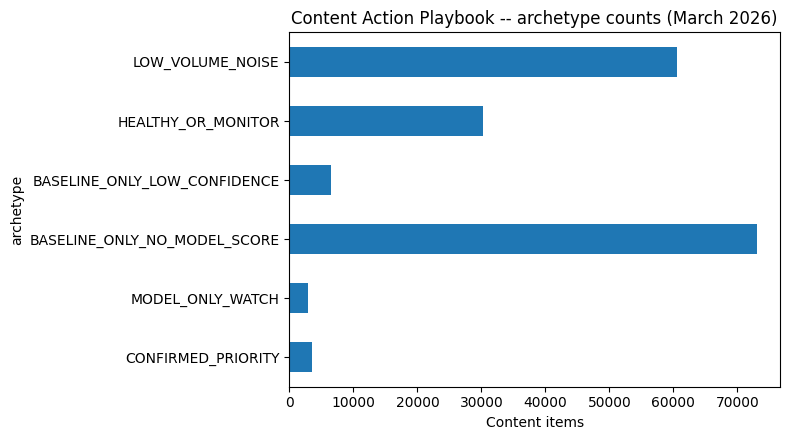

Wrote work/figures/w07_archetype_counts.png (committed)
Wrote work/outputs/w07_playbook_metrics.json (committed)


In [ ]:
import json
import matplotlib.pyplot as plt

os.makedirs("work/outputs", exist_ok=True)
os.makedirs("work/figures", exist_ok=True)

# 1. Full ranked queue -- regenerated every run, never committed
queue.to_csv("work/outputs/w07_action_queue.csv", index=False)
print(f"Wrote {len(queue)} rows to work/outputs/w07_action_queue.csv (gitignored)")

# 2. One figure worth reusing in the paper
archetype_order = ["CONFIRMED_PRIORITY", "MODEL_ONLY_WATCH", "BASELINE_ONLY_NO_MODEL_SCORE",
                    "BASELINE_ONLY_LOW_CONFIDENCE", "HEALTHY_OR_MONITOR", "LOW_VOLUME_NOISE"]
archetype_counts = queue["archetype"].value_counts().reindex(archetype_order).fillna(0)

fig, ax = plt.subplots(figsize=(8, 4.5))
archetype_counts.plot(kind="barh", ax=ax)
ax.set_xlabel("Content items")
ax.set_title("Content Action Playbook -- archetype counts (March 2026)")
plt.tight_layout()
fig.savefig("work/figures/w07_archetype_counts.png", dpi=150)
plt.show()
print("Wrote work/figures/w07_archetype_counts.png (committed)")

# 3. Metrics JSON -- the receipt, no raw rows, safe to commit
playbook_metrics = {
    "n_scored": int(len(queue)),
    "archetype_counts": {k: int(v) for k, v in archetype_counts.items()},
    "requires_human_review": int(queue["requires_human_review"].sum()),
    "never_automate": int(queue["never_automate"].sum()),
    "monitoring_baseline": monitoring_baseline,
}
with open("work/outputs/w07_playbook_metrics.json", "w") as f:
    json.dump(playbook_metrics, f, indent=2)
print("Wrote work/outputs/w07_playbook_metrics.json (committed)")

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.